# Benchmark de quantização KMNIST — notebook reprodutível

Este notebook lê as tabelas auditáveis geradas a partir dos artefatos do benchmark, confirma as verificações de integridade e recria os gráficos principais.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS = Path.cwd()
if not (ANALYSIS / 'run_summary.csv').exists():
    ANALYSIS = Path('/mnt/e/tcc-benchmark/outputs/kmnist-quantization-2026-08-09/analysis')
assert (ANALYSIS / 'run_summary.csv').exists(), f'Pasta analysis não encontrada: {ANALYSIS}'
runs = pd.read_csv(ANALYSIS / 'run_summary.csv')
deltas = pd.read_csv(ANALYSIS / 'metric_deltas_vs_fp32.csv')
epochs = pd.read_csv(ANALYSIS / 'training_epochs.csv')
quality = json.loads((ANALYSIS / 'data_quality.json').read_text(encoding='utf-8'))
summary = json.loads((ANALYSIS / 'analysis_summary.json').read_text(encoding='utf-8'))
print('Pasta de análise:', ANALYSIS)
print('Validação passou:', quality['passed'])
pd.DataFrame({'checagem': quality['checks'].keys(), 'resultado': quality['checks'].values()})

Pasta de análise: /mnt/e/tcc-benchmark/outputs/kmnist-quantization-2026-08-09/analysis
Validação passou: True


,checagem,resultado
0,top_level_status_completed,True
1,zero_reported_failures,True
2,all_five_variants_present,True
3,all_variant_statuses_completed,True
4,all_training_runs_have_50_epochs,True
5,all_training_summaries_report_50_epochs,True
6,fixed_batch_256,True
7,augmentation_disabled,True
8,memory_growth_enabled,True
9,same_split_fingerprint,True


## Métricas de teste e diferenças para FP32

In [2]:
metrics_view = runs[['label', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'macro_ovr_auc', 'logit_mse_vs_fp32', 'prediction_agreement_vs_fp32']].copy()
for col in ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'macro_ovr_auc', 'prediction_agreement_vs_fp32']:
    metrics_view[col] = metrics_view[col].map(lambda x: f'{x:.3%}' if pd.notna(x) else '—')
metrics_view['logit_mse_vs_fp32'] = metrics_view['logit_mse_vs_fp32'].map(lambda x: f'{x:.6f}' if pd.notna(x) else '—')
metrics_view

,label,accuracy,macro_precision,macro_recall,macro_f1,macro_ovr_auc,logit_mse_vs_fp32,prediction_agreement_vs_fp32
0,FP32,97.857%,97.865%,97.857%,97.855%,99.945%,0.000000,100.000%
1,FP16,97.295%,97.307%,97.295%,97.296%,99.918%,5.753087,97.352%
2,INT8-QAT,97.724%,97.733%,97.724%,97.725%,99.941%,4.211951,97.629%
3,INT4-QAT (emulado),98.010%,98.015%,98.010%,98.010%,99.956%,8.096385,97.457%
4,INT8-PTQ,96.648%,96.677%,96.648%,96.640%,99.868%,1.583283,97.495%


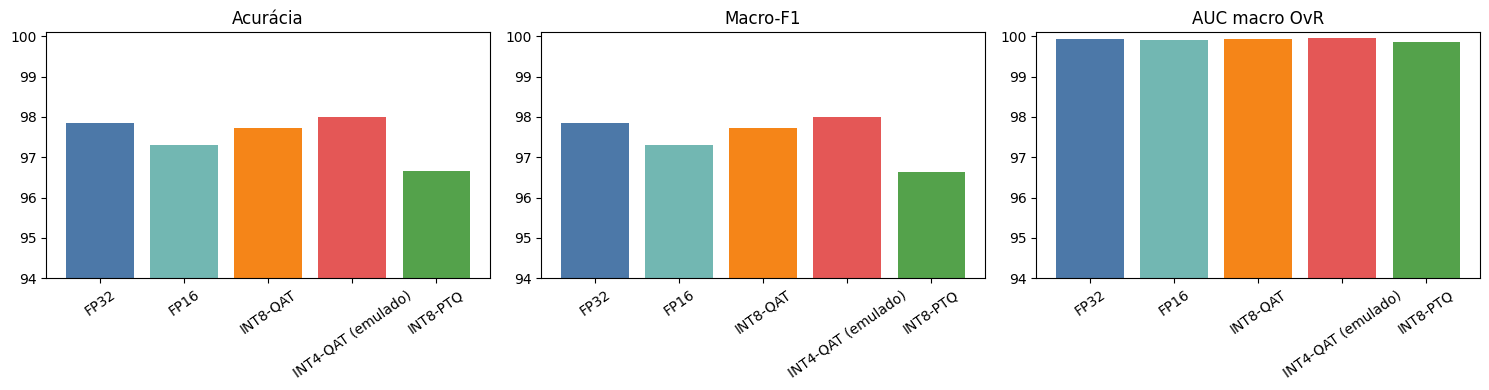

In [3]:
colors = {'FP32':'#4C78A8','FP16':'#72B7B2','INT8-QAT':'#F58518','INT4-QAT (emulado)':'#E45756','INT8-PTQ':'#54A24B'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes, ['accuracy','macro_f1','macro_ovr_auc'], ['Acurácia','Macro-F1','AUC macro OvR']):
    values = runs[metric] * 100
    ax.bar(runs['label'], values, color=[colors[x] for x in runs['label']])
    ax.set_title(title); ax.tick_params(axis='x', rotation=35); ax.set_ylim(min(94, values.min()-1), 100.1)
plt.tight_layout()

## Convergência e telemetria de treino

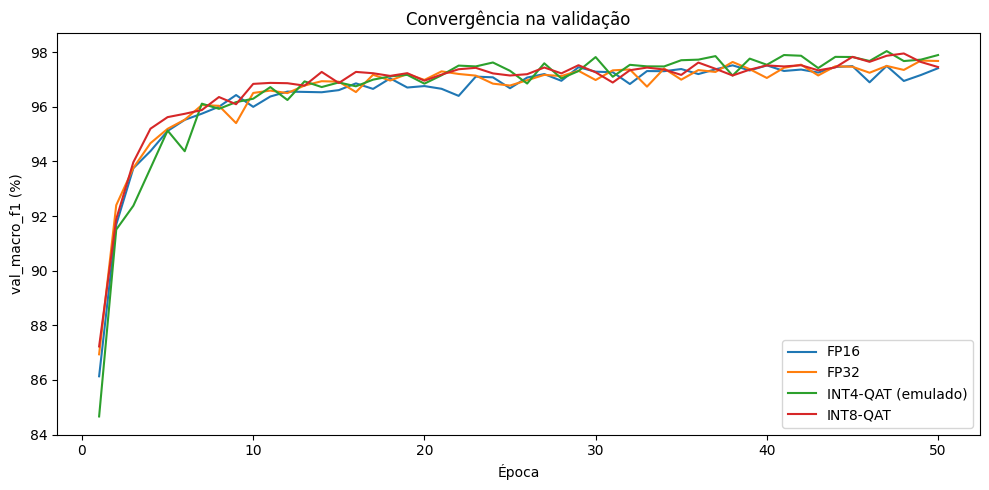

In [4]:
metric = 'val_macro_f1' if 'val_macro_f1' in epochs.columns else 'val_accuracy'
fig, ax = plt.subplots(figsize=(10, 5))
for variant, part in epochs.groupby('variant'):
    label = runs.loc[runs.variant.eq(variant), 'label'].iloc[0]
    ax.plot(part['epoch'], part[metric] * 100, label=label)
ax.set(xlabel='Época', ylabel=f'{metric} (%)', title='Convergência na validação')
ax.legend(); plt.tight_layout()

In [5]:
train_view = runs[runs.variant != 'int8_ptq'][['label','training_seconds','mean_epoch_seconds','train_examples_per_second','gpu_util_mean_percent','gpu_memory_peak_gib','process_rss_peak_gib']].copy()
train_view.round(2)

,label,training_seconds,mean_epoch_seconds,train_examples_per_second,gpu_util_mean_percent,gpu_memory_peak_gib,process_rss_peak_gib
0,FP32,2778.93,59.13,830.71,39.04,4.19,3.03
1,FP16,2828.20,56.56,869.56,32.21,4.21,3.53
2,INT8-QAT,1147.69,22.95,2159.42,45.34,4.52,3.09
3,INT4-QAT (emulado),1169.80,23.40,2118.04,46.13,4.70,3.21


## Implantação LiteRT/CPU

In [6]:
deploy_view = runs[['label','serialized_litert_mib','estimated_deployment_mib','litert_status','litert_validity','inference_latency_ms','inference_throughput_eps','inference_rss_peak_mib']].copy()
deploy_view.round(3)

,label,serialized_litert_mib,estimated_deployment_mib,litert_status,litert_validity,inference_latency_ms,inference_throughput_eps,inference_rss_peak_mib
0,FP32,0.813,0.767,completed,float_or_hybrid,76.438,3312.047,1617.637
1,FP16,NaN,0.387,failed,failed,NaN,NaN,NaN
2,INT8-QAT,0.298,0.198,completed,float_or_hybrid,49.081,5141.263,1875.812
3,INT4-QAT (emulado),NaN,0.103,not_exported,emulated_int4,NaN,NaN,NaN
4,INT8-PTQ,0.297,0.197,completed,float_or_hybrid,63.356,3610.371,2055.699


## Conclusões e limites

O dicionário abaixo contém as conclusões calculadas pelo pipeline. O relatório Markdown fornece a interpretação completa e as ressalvas: uma única seed, INT4 emulado, FP16 sem LiteRT e INT8-PTQ classificado como híbrido.

In [7]:
summary['key_findings']

['Melhor acurácia: INT4-QAT (emulado) (98.010%).',
 'INT8-QAT: -0.133% de diferença de acurácia contra FP32.',
 'INT8-PTQ: 0.297 MiB e 3610.4 exemplos/s em LiteRT/CPU; validade float_or_hybrid.',
 'INT4-QAT é um resultado numérico emulado, não um artefato INT4 LiteRT implantável.']